# Implementing Logistic Regression with numpy

In this problem, you will need to write python codes and build logistic regression classifiers on breast cancer dataset to predict whether the cancer is malignant or benign on the patients. The dataset contains 569 samples and 30 features. You may refer to https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic) for more information about the dataset.

Your implementations should include:
- Load data, clean data and partition them into training and testing data.
- Build logistic regression and L2-regularized logistic regression models.
- Implement three gradient descent algorithms for each model: Batch Gradient Descent (GD), Mini-Batch Gradient Descent (MB-SGD) and Stochastic Gradient Descent (SGD).
- Compare the loss curve of three gradient descent algorithms (GD/MB-SGD/SGD).
- Compare logistic regression and regularized version in terms of training and testing error.
- Try to tune different parameters (regularization parameter, learning rate, etc.) to see their effects.

You could use sklearn or any other packages to load and process the data, but you can not directly use the package to train the model.


### Name: Mandar Sanju Bavdane


#### For this assignment, you will build 6 models. You need to train Logistic Regression/Regularized Logistic Regression each with Batch Gradient Descent, Stochastic Gradient Descent and Mini Batch Gradient Descent. Also you should plot their objective values versus epochs and compare their training and testing accuracies. You will need to tune the parameters a little bit to obtain reasonable results.

#### You do not have to follow the following procedure. You may implement your own functions and methods, but you need to show your results and plots.

In [705]:
# Load Packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Data processing

- Download the Breast Cancer dataset from canvas or from https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)
- Load the data.
- Preprocess the data.

## 1.1. Load the data

In [706]:
df = pd.read_csv('data.csv', header=None)
print(df.shape)
df.head()

(569, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1.2 Examine and clean data

In [707]:
# Some columns may not be useful for the model (For example, the first column contains ID number which may be irrelavant). 
# You need to get rid of the ID number feature.
# Also you should transform target labels in the second column from 'B' and 'M' to 1 and -1.

# Drop the id column
df = df.drop(columns=[0])

# Labels B -> 1, M -> -1
x = df.drop(columns=[1])
y = df[1].map({'B': 1, 'M': -1}).values.reshape(-1, 1)

print('Missing values:', x.isnull().sum().sum())
print('Shape of x:', x.shape)
print('Shape of y:', y.shape)
print('Benign:', np.sum(y == 1), ' Malignant:', np.sum(y == -1))



Missing values: 0
Shape of x: (569, 30)
Shape of y: (569, 1)
Benign: 357  Malignant: 212


In [708]:
print(df.shape)
df.sample(5)

(569, 31)


,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
387,B,13.880,16.16,88.37,596.6,0.07026,0.04831,0.02045,0.008507,0.1607,...,15.510,19.97,99.66,745.3,0.08484,0.12330,0.10910,0.04537,0.2542,0.06623
357,B,13.870,16.21,88.52,593.7,0.08743,0.05492,0.01502,0.020880,0.1424,...,15.110,25.58,96.74,694.4,0.11530,0.10080,0.05285,0.05556,0.2362,0.07113
151,B,8.219,20.70,53.27,203.9,0.09405,0.13050,0.13210,0.021680,0.2222,...,9.092,29.72,58.08,249.8,0.16300,0.43100,0.53810,0.07879,0.3322,0.14860
311,B,14.610,15.69,92.68,664.9,0.07618,0.03515,0.01447,0.018770,0.1632,...,16.460,21.75,103.70,840.8,0.10110,0.07087,0.04746,0.05813,0.2530,0.05695
459,B,9.755,28.20,61.68,290.9,0.07984,0.04626,0.01541,0.010430,0.1621,...,10.670,36.92,68.03,349.9,0.11100,0.11090,0.07190,0.04866,0.2321,0.07211


## 1.3. Partition to training and testing sets

In [709]:
# You can partition using 80% training data and 20% testing data. It is a commonly used ratio in machinel learning.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', x_train.shape, y_train.shape)
print('Test: ', x_test.shape, y_test.shape)


Train: (455, 30) (455, 1)
Test:  (114, 30) (114, 1)


## 1.4. Feature scaling

Use the standardization to trainsform both training and test features

In [710]:
# Standardization
import numpy

# calculate mu and sig using the training set
d = x_train.shape[1]
mu = numpy.mean(x_train.values, axis=0).reshape(1, d)
sig = numpy.std(x_train.values, axis=0).reshape(1, d)

# transform the training features
x_train = (x_train - mu) / (sig + 1E-6)

# transform the test features
x_test = (x_test - mu) / (sig + 1E-6)

print('test mean = ')
print(numpy.mean(x_test, axis=0))

print('test std = ')
print(numpy.std(x_test, axis=0))

test mean = 
2     0.085785
3     0.047963
4     0.085170
5     0.091955
6     0.071599
7     0.044072
8    -0.024083
9     0.073835
10    0.096790
11   -0.015471
12    0.115674
13   -0.016400
14    0.110162
15    0.130811
16   -0.067993
17   -0.016191
18   -0.101685
19    0.097981
20   -0.134843
21   -0.004276
22    0.096334
23    0.024020
24    0.095722
25    0.104435
26    0.008790
27   -0.001985
28   -0.101576
29    0.052514
30   -0.061058
31    0.000326
dtype: float64
test std = 
2     1.032942
3     0.875678
4     1.028845
5     1.095109
6     1.207493
7     0.932317
8     0.870138
9     0.983166
10    0.873264
11    0.929812
12    1.162558
13    0.812857
14    1.113700
15    1.385546
16    0.764185
17    0.839296
18    0.585474
19    0.898015
20    0.660841
21    0.729293
22    1.062085
23    0.935670
24    1.057461
25    1.137826
26    1.061984
27    0.918942
28    0.813318
29    0.918669
30    0.763044
31    0.903282
dtype: float64


In [711]:
# convert to numpy arrays for the rest of the notebook
x_train = np.asarray(x_train)
x_test = np.asarray(x_test)

# 2.  Logistic Regression Model

The objective function is $Q (w; X, y) = \frac{1}{n} \sum_{i=1}^n \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $.

When $\lambda = 0$, the model is a regular logistric regression and when $\lambda > 0$, it essentially becomes a regularized logistric regression.

In [712]:
# Calculate the objective function value, or loss
# Inputs:
#     w: weight: d-by-1 vector
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: regularization parameter: scalar
# Return:
#     objective function value, or loss (scalar)

def objective(w, x, y, lam):
    # Object function based on the above expression
    yxw = y * np.dot(x, w)                 # nx1: y_i * x_i^T w
    loss = np.mean(np.logaddexp(0, -yxw))  
    reg = lam / 2 * np.sum(w * w)          
    return loss + reg

In [713]:
w0 = np.zeros((d, 1))
print(objective(w0, x_train, y_train, 0))

0.6931471805599453


# 3. Numerical optimization

## 3.1. Gradient descent


The gradient at $w$ for regularized logistic regression is  $g = - \frac{1}{n} \sum_{i=1}^n \frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$

In [714]:
# Calculate the gradient
# Inputs:
#     w: weight: d-by-1 matrix
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: regularization parameter: scalar
# Return:
#     g: gradient: d-by-1 matrix

# Gradient based on the above expression
def gradient(w, x, y, lam):
    yxw = y * np.dot(x, w)                                    # nx1
    coef = -y / (1 + np.exp(yxw))                             # nx1
    g = np.mean(coef * x, axis=0).reshape(-1, 1) + lam * w    # dx1
    return g

In [715]:

# Gradient descent for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value

# Gradient descent for solving logistic regression
def gradient_descent(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        g = gradient(w, x, y, lam)
        w = w - learning_rate * g
        objvals[t] = objective(w, x, y, lam)
        print(f'Objective value at epoch t={t} is {objvals[t]:.4f}')
    return w, objvals

Use gradient_descent function to obtain your optimal weights and a list of objective values over each epoch.

In [716]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 1.0
w_gd, objvals_gd = gradient_descent(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1713
Objective value at epoch t=1 is 0.1353
Objective value at epoch t=2 is 0.1180
Objective value at epoch t=3 is 0.1101
Objective value at epoch t=4 is 0.1051
Objective value at epoch t=5 is 0.1013
Objective value at epoch t=6 is 0.0982
Objective value at epoch t=7 is 0.0954
Objective value at epoch t=8 is 0.0930
Objective value at epoch t=9 is 0.0909
Objective value at epoch t=10 is 0.0890
Objective value at epoch t=11 is 0.0873
Objective value at epoch t=12 is 0.0858
Objective value at epoch t=13 is 0.0844
Objective value at epoch t=14 is 0.0831
Objective value at epoch t=15 is 0.0819
Objective value at epoch t=16 is 0.0808
Objective value at epoch t=17 is 0.0798
Objective value at epoch t=18 is 0.0789
Objective value at epoch t=19 is 0.0780
Objective value at epoch t=20 is 0.0771
Objective value at epoch t=21 is 0.0764
Objective value at epoch t=22 is 0.0756
Objective value at epoch t=23 is 0.0749
Objective value at epoch t=24 is 0.0743
Objective 

In [717]:
# Train Regularized Logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 1.0
w_gd_reg, objvals_gd_reg = gradient_descent(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1814
Objective value at epoch t=1 is 0.1460
Objective value at epoch t=2 is 0.1300
Objective value at epoch t=3 is 0.1235
Objective value at epoch t=4 is 0.1198
Objective value at epoch t=5 is 0.1171
Objective value at epoch t=6 is 0.1149
Objective value at epoch t=7 is 0.1131
Objective value at epoch t=8 is 0.1115
Objective value at epoch t=9 is 0.1102
Objective value at epoch t=10 is 0.1091
Objective value at epoch t=11 is 0.1081
Objective value at epoch t=12 is 0.1073
Objective value at epoch t=13 is 0.1065
Objective value at epoch t=14 is 0.1059
Objective value at epoch t=15 is 0.1053
Objective value at epoch t=16 is 0.1047
Objective value at epoch t=17 is 0.1042
Objective value at epoch t=18 is 0.1038
Objective value at epoch t=19 is 0.1034
Objective value at epoch t=20 is 0.1031
Objective value at epoch t=21 is 0.1027
Objective value at epoch t=22 is 0.1024
Objective value at epoch t=23 is 0.1022
Objective value at epoch t=24 is 0.1019
Objective 

## 3.2. Stochastic gradient descent (SGD)

Define new objective function $Q_i (w) = \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $. 

The stochastic gradient at $w$ is $g_i = \frac{\partial Q_i }{ \partial w} = -\frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [718]:

# Calculate the objective Q_i and the gradient of Q_i
# Inputs:
#     w: weights: d-by-1 matrix
#     xi: data: 1-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

# Calculate the objective Q_i and the gradient of Q_i
def stochastic_objective_gradient(w, xi, yi, lam):
    yxw = (yi * np.dot(xi, w)).item()                                
    obj = np.logaddexp(0, -yxw) + lam / 2 * np.sum(w * w)            # Q_i
    g = (-yi / (1 + np.exp(yxw))) * xi.reshape(-1, 1) + lam * w      # dx1
    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples.
2. Each epoch has $n$ iterations. In every iteration, use 1 sample, and compute the gradient and objective using the ``stochastic_objective_gradient`` function. In the next iteration, use the next sample, and so on.

In [719]:
# SGD for solving logistic regression
# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def sgd(x, y, lam, learning_rate, w, max_epoch=100):
    n = x.shape[0]
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        # random permutation of n samples
        rand_indices = np.random.permutation(n)
        x_rand = x[rand_indices, :]
        y_rand = y[rand_indices, :]

        objval = 0
        for i in range(n):
            xi = x_rand[i, :].reshape(1, -1)   # 1xd
            yi = float(y_rand[i, 0])           # scalar
            obj, g = stochastic_objective_gradient(w, xi, yi, lam)
            objval += obj
            w = w - learning_rate * g

        learning_rate *= 0.9                   
        objvals[t] = objval / n                # average Q_i over the epoch
        print(f'Objective value at epoch t={t} is {objvals[t]:.4f}')
    return w, objvals

Use sgd function to obtain your optimal weights and a list of objective values over each epoch.

In [720]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 0.1
w_sgd, objvals_sgd = sgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1175
Objective value at epoch t=1 is 0.0663
Objective value at epoch t=2 is 0.0637
Objective value at epoch t=3 is 0.0567
Objective value at epoch t=4 is 0.0574
Objective value at epoch t=5 is 0.0543
Objective value at epoch t=6 is 0.0532
Objective value at epoch t=7 is 0.0517
Objective value at epoch t=8 is 0.0516
Objective value at epoch t=9 is 0.0503
Objective value at epoch t=10 is 0.0500
Objective value at epoch t=11 is 0.0495
Objective value at epoch t=12 is 0.0487
Objective value at epoch t=13 is 0.0483
Objective value at epoch t=14 is 0.0481
Objective value at epoch t=15 is 0.0478
Objective value at epoch t=16 is 0.0473
Objective value at epoch t=17 is 0.0473
Objective value at epoch t=18 is 0.0470
Objective value at epoch t=19 is 0.0468
Objective value at epoch t=20 is 0.0466
Objective value at epoch t=21 is 0.0465
Objective value at epoch t=22 is 0.0463
Objective value at epoch t=23 is 0.0462
Objective value at epoch t=24 is 0.0461
Objective 

In [721]:
# Train regularized logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 0.1
w_sgd_reg, objvals_sgd_reg = sgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1415
Objective value at epoch t=1 is 0.1065
Objective value at epoch t=2 is 0.1076
Objective value at epoch t=3 is 0.1052
Objective value at epoch t=4 is 0.1052
Objective value at epoch t=5 is 0.1039
Objective value at epoch t=6 is 0.1032
Objective value at epoch t=7 is 0.1024
Objective value at epoch t=8 is 0.1022
Objective value at epoch t=9 is 0.1017
Objective value at epoch t=10 is 0.1018
Objective value at epoch t=11 is 0.1014
Objective value at epoch t=12 is 0.1007
Objective value at epoch t=13 is 0.1003
Objective value at epoch t=14 is 0.1006
Objective value at epoch t=15 is 0.0998
Objective value at epoch t=16 is 0.0998
Objective value at epoch t=17 is 0.0998
Objective value at epoch t=18 is 0.0996
Objective value at epoch t=19 is 0.0994
Objective value at epoch t=20 is 0.0993
Objective value at epoch t=21 is 0.0992
Objective value at epoch t=22 is 0.0991
Objective value at epoch t=23 is 0.0989
Objective value at epoch t=24 is 0.0989
Objective 

## 3.3 Mini-Batch Gradient Descent (MBGD)

Define $Q_I (w) = \frac{1}{b} \sum_{i \in I} \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $, where $I$ is a set containing $b$ indices randomly drawn from $\{ 1, \cdots , n \}$ without replacement.

The stochastic gradient at $w$ is $g_I = \frac{\partial Q_I }{ \partial w} = \frac{1}{b} \sum_{i \in I} \frac{- y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [722]:
# Calculate the objective Q_I and the gradient of Q_I
# Inputs:
#     w: weights: d-by-b matrix
#     xi: data: b-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

def mb_objective_gradient(w, xi, yi, lam):
    yxw = yi * np.dot(xi, w)                                          # bx1
    obj = np.mean(np.logaddexp(0, -yxw)) + lam / 2 * np.sum(w * w)    # Q_I
    coef = -yi / (1 + np.exp(yxw))                                    # bx1
    g = np.mean(coef * xi, axis=0).reshape(-1, 1) + lam * w           # dx1
    return obj, g

Hints:
1. In every epoch, randomly permute the $n$ samples (just like SGD).
2. Each epoch has $\frac{n}{b}$ iterations. In every iteration, use $b$ samples, and compute the gradient and objective using the ``mb_objective_gradient`` function. In the next iteration, use the next $b$ samples, and so on.

In [723]:
# MBGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

batch_size = 8

def mbgd(x, y, lam, learning_rate, w, max_epoch=100):
    n = x.shape[0]
    num_batches = int(np.ceil(n / batch_size))
    objvals = np.zeros(max_epoch)
    for t in range(max_epoch):
        # random permutation of n samples
        rand_indices = np.random.permutation(n)
        x_rand = x[rand_indices, :]
        y_rand = y[rand_indices, :]

        objval = 0
        for i in range(num_batches):
            xi = x_rand[i * batch_size:(i + 1) * batch_size, :]   # bxd
            yi = y_rand[i * batch_size:(i + 1) * batch_size, :]   # bx1
            obj, g = mb_objective_gradient(w, xi, yi, lam)
            objval += obj
            w = w - learning_rate * g

        learning_rate *= 0.9                  # decrease learning rate after each epoch
        objvals[t] = objval / num_batches     
        print(f'Objective value at epoch t={t} is {objvals[t]:.4f}')
    return w, objvals

Use mbgd function to obtain your optimal weights and a list of objective values over each epoch.

In [724]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 0
w_init = np.zeros((d, 1))
learning_rate = 0.5
w_mbgd, objvals_mbgd = mbgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1312
Objective value at epoch t=1 is 0.0723
Objective value at epoch t=2 is 0.0669
Objective value at epoch t=3 is 0.0610
Objective value at epoch t=4 is 0.0596
Objective value at epoch t=5 is 0.0569
Objective value at epoch t=6 is 0.0559
Objective value at epoch t=7 is 0.0553
Objective value at epoch t=8 is 0.0539
Objective value at epoch t=9 is 0.0531
Objective value at epoch t=10 is 0.0522
Objective value at epoch t=11 is 0.0520
Objective value at epoch t=12 is 0.0515
Objective value at epoch t=13 is 0.0510
Objective value at epoch t=14 is 0.0508
Objective value at epoch t=15 is 0.0504
Objective value at epoch t=16 is 0.0501
Objective value at epoch t=17 is 0.0498
Objective value at epoch t=18 is 0.0497
Objective value at epoch t=19 is 0.0495
Objective value at epoch t=20 is 0.0493
Objective value at epoch t=21 is 0.0492
Objective value at epoch t=22 is 0.0491
Objective value at epoch t=23 is 0.0489


Objective value at epoch t=24 is 0.0489
Objective value at epoch t=25 is 0.0488
Objective value at epoch t=26 is 0.0487
Objective value at epoch t=27 is 0.0486
Objective value at epoch t=28 is 0.0485
Objective value at epoch t=29 is 0.0485
Objective value at epoch t=30 is 0.0484
Objective value at epoch t=31 is 0.0487
Objective value at epoch t=32 is 0.0484
Objective value at epoch t=33 is 0.0483
Objective value at epoch t=34 is 0.0482
Objective value at epoch t=35 is 0.0483
Objective value at epoch t=36 is 0.0482
Objective value at epoch t=37 is 0.0499
Objective value at epoch t=38 is 0.0485
Objective value at epoch t=39 is 0.0482
Objective value at epoch t=40 is 0.0481
Objective value at epoch t=41 is 0.0481
Objective value at epoch t=42 is 0.0481
Objective value at epoch t=43 is 0.0482
Objective value at epoch t=44 is 0.0480
Objective value at epoch t=45 is 0.0487
Objective value at epoch t=46 is 0.0480
Objective value at epoch t=47 is 0.0480
Objective value at epoch t=48 is 0.0480


In [725]:
# Train Regularized Logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(0)
lam = 1E-2
w_init = np.zeros((d, 1))
learning_rate = 0.5
w_mbgd_reg, objvals_mbgd_reg = mbgd(x_train, y_train, lam, learning_rate, w_init, max_epoch=100)

Objective value at epoch t=0 is 0.1499
Objective value at epoch t=1 is 0.1054
Objective value at epoch t=2 is 0.1052
Objective value at epoch t=3 is 0.1027
Objective value at epoch t=4 is 0.1025
Objective value at epoch t=5 is 0.1012
Objective value at epoch t=6 is 0.1014
Objective value at epoch t=7 is 0.1015
Objective value at epoch t=8 is 0.1007
Objective value at epoch t=9 is 0.1004
Objective value at epoch t=10 is 0.1001
Objective value at epoch t=11 is 0.1001
Objective value at epoch t=12 is 0.0997
Objective value at epoch t=13 is 0.0995
Objective value at epoch t=14 is 0.0997
Objective value at epoch t=15 is 0.0991
Objective value at epoch t=16 is 0.0991
Objective value at epoch t=17 is 0.0990
Objective value at epoch t=18 is 0.0989
Objective value at epoch t=19 is 0.0988
Objective value at epoch t=20 is 0.0987
Objective value at epoch t=21 is 0.0986
Objective value at epoch t=22 is 0.0986
Objective value at epoch t=23 is 0.0985
Objective value at epoch t=24 is 0.0986
Objective 

# 4. Compare GD, SGD, MBGD

### Plot objective function values against epochs.

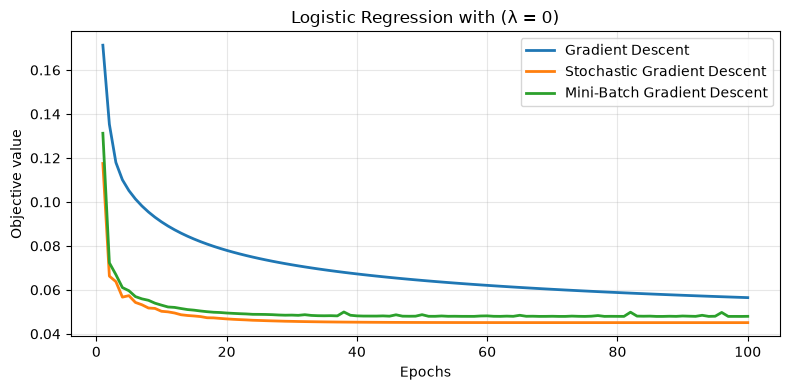

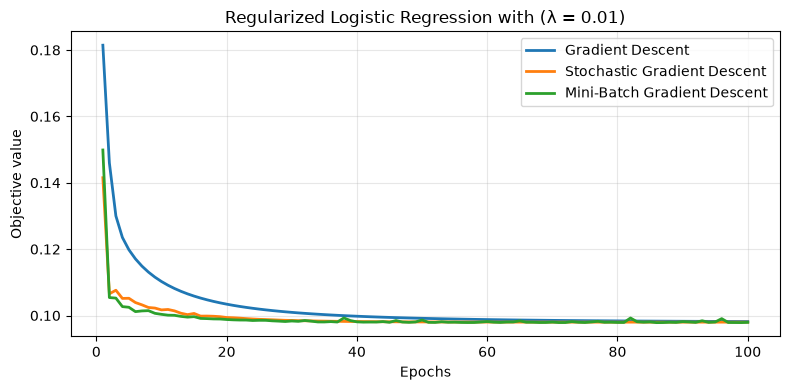

In [726]:
import matplotlib.pyplot as plt
%matplotlib inline

epochs = np.arange(1, 101)

# Logistic regression (lam = 0)
fig = plt.figure(figsize=(8, 4))
plt.plot(epochs, objvals_gd, label='Gradient Descent', linewidth=2)
plt.plot(epochs, objvals_sgd, label='Stochastic Gradient Descent', linewidth=2)
plt.plot(epochs, objvals_mbgd, label='Mini-Batch Gradient Descent', linewidth=2)
plt.title('Logistic Regression with (λ = 0)')
plt.xlabel('Epochs')
plt.ylabel('Objective value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Regularized logistic regression (lam = 0.01)
fig = plt.figure(figsize=(8, 4))
plt.plot(epochs, objvals_gd_reg, label='Gradient Descent', linewidth=2)
plt.plot(epochs, objvals_sgd_reg, label='Stochastic Gradient Descent', linewidth=2)
plt.plot(epochs, objvals_mbgd_reg, label='Mini-Batch Gradient Descent', linewidth=2)
plt.title('Regularized Logistic Regression with (λ = 0.01)')
plt.xlabel('Epochs')
plt.ylabel('Objective value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Comparison of GD, SGD and MBGD:**
- SGD and MBGD reduce the objective much faster per epoch than batch GD, because they make many updates per epoch (455 for SGD, 57 for MBGD with b = 8) versus a single update for GD.
- For plain logistic regression (λ = 0), GD is still decreasing slowly at epoch 100 (0.0565), while SGD (0.0451) and MBGD (0.0480) have already leveled off at a lower value.
- For regularized logistic regression (λ = 0.01), all three methods converge to the same minimum (about 0.098), since the regularized objective has a unique solution. GD takes about 40 epochs to get there; SGD and MBGD take about 10.
- GD gives the smoothest curve. SGD and MBGD curves have small bumps because each update uses only a random subset of the data.
- Note: GD records the full training objective after each epoch, while SGD and MBGD record the average batch loss during the epoch.

# 5. Prediction
### Compare the training and testing accuracy for logistic regression and regularized logistic regression.

In [727]:
# Predict class label
# Inputs:
#     w: weights: d-by-1 matrix
#     X: data: m-by-d matrix
# Return:
#     f: m-by-1 matrix, the predictions

def predict(w, X):
    xw = np.dot(X, w)        # mx1
    f = np.sign(xw)          # +1 --> (benign) | -1 --> (malignant)
    f[f == 0] = 1            
    return f

In [728]:
def calculate_error(w, x, y):
    y_pred = predict(w,x)
    score = np.mean(y != y_pred)
    return score

In [729]:
# evaluate training error of logistic regression and regularized version
models = {
    'Gradient Descent': w_gd,                'Regularized Gradient Descent': w_gd_reg,
    'Stochastic Gradient Descent': w_sgd,    'Regularized Stochastic Gradient Descent': w_sgd_reg,
    'Mini-Batch Gradient Descent': w_mbgd,   'Regularized Mini-Batch Gradient Descent': w_mbgd_reg,
}

print(f"{'Model Name':<42} | {'Training Error':<14} | {'Accuracy':<10}")
print("-" * 74)

for name, w in models.items():
    train_err = np.mean(predict(w, x_train) != y_train)
    accuracy = 1 - train_err
    print(f"{name:<42} | {train_err:<14.4f} | {accuracy:<10.4f}")


Model Name                                 | Training Error | Accuracy  
--------------------------------------------------------------------------
Gradient Descent                           | 0.0132         | 0.9868    
Regularized Gradient Descent               | 0.0132         | 0.9868    
Stochastic Gradient Descent                | 0.0110         | 0.9890    
Regularized Stochastic Gradient Descent    | 0.0110         | 0.9890    
Mini-Batch Gradient Descent                | 0.0110         | 0.9890    
Regularized Mini-Batch Gradient Descent    | 0.0110         | 0.9890    


In [730]:
# evaluate testing error of logistic regression and regularized version
print(f"{'Model Name':<42} | {'Testing Error':<14} | {'Accuracy':<10}")
print("-" * 74)

for name, w in models.items():
    test_err = np.mean(predict(w, x_test) != y_test)
    accuracy = 1 - test_err
    print(f"{name:<42} | {test_err:<14.4f} | {accuracy:<10.4f}")


Model Name                                 | Testing Error  | Accuracy  
--------------------------------------------------------------------------
Gradient Descent                           | 0.0351         | 0.9649    
Regularized Gradient Descent               | 0.0351         | 0.9649    
Stochastic Gradient Descent                | 0.0351         | 0.9649    
Regularized Stochastic Gradient Descent    | 0.0351         | 0.9649    
Mini-Batch Gradient Descent                | 0.0351         | 0.9649    
Regularized Mini-Batch Gradient Descent    | 0.0351         | 0.9649    


**Comparison of logistic regression and regularized logistic regression:**
- Training accuracy is 98.68% (GD) and 98.90% (SGD, MBGD) for both the regular and regularized models.
- Testing accuracy is 96.49% for all six models (4 of 114 test samples misclassified).
- With λ = 0.01, regularization does not change the training or testing error. The dataset has many more samples (455) than features (30) and the features are standardized, so the unregularized model does not overfit much. The small gap between training error (~1.1%) and testing error (~3.5%) confirms this.
- The choice of optimizer affects convergence speed but not the final accuracy.

# 6. Parameters tuning

### In this section, you may try different combinations of parameters (regularization value, learning rate, etc) to see their effects on the model.

### 1. Setup and Validaton

In [731]:
import time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# silence the per-epoch prints of the training functions
import contextlib, io
def quiet(f, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return f(*args, **kwargs)

def error_rate(w, X, y):
    return np.mean(predict(w, X) != y)

def log_loss(w, X, y):
    return objective(w, X, y, 0)          # pure logistic loss (lam = 0), comparable across lambdas

# Hold out 20% of the TRAINING data as a validation set, so hyperparameters are chosen
# without ever looking at the test set.
rng = np.random.RandomState(7)
perm = rng.permutation(x_train.shape[0])
n_val = int(0.2 * len(perm))
val_idx, fit_idx = perm[:n_val], perm[n_val:]
x_fit, y_fit = x_train[fit_idx], y_train[fit_idx]
x_val, y_val = x_train[val_idx], y_train[val_idx]
print('fit:', x_fit.shape, ' validation:', x_val.shape, ' test (untouched):', x_test.shape)

fit: (364, 30)  validation: (91, 30)  test (untouched): (114, 30)


### 2. Grid search over (lambda, learning rate) with batch GD


Validation log-loss (GD, 300 epochs)


lr,0.01,0.10,0.50,1.00
lambda,,,,
0.000,0.1305,0.0531,0.0395,0.0520
0.001,0.1307,0.0539,0.0407,0.0471
0.010,0.1324,0.0608,0.0533,0.0533
0.100,0.1492,0.1131,0.1130,0.1130
0.300,0.1849,0.1734,0.1734,0.1734


Validation error (GD, 300 epochs)


lr,0.01,0.10,0.50,1.00
lambda,,,,
0.000,0.033,0.011,0.000,0.022
0.001,0.033,0.011,0.000,0.022
0.010,0.033,0.011,0.000,0.000
0.100,0.033,0.022,0.022,0.022
0.300,0.033,0.022,0.022,0.022


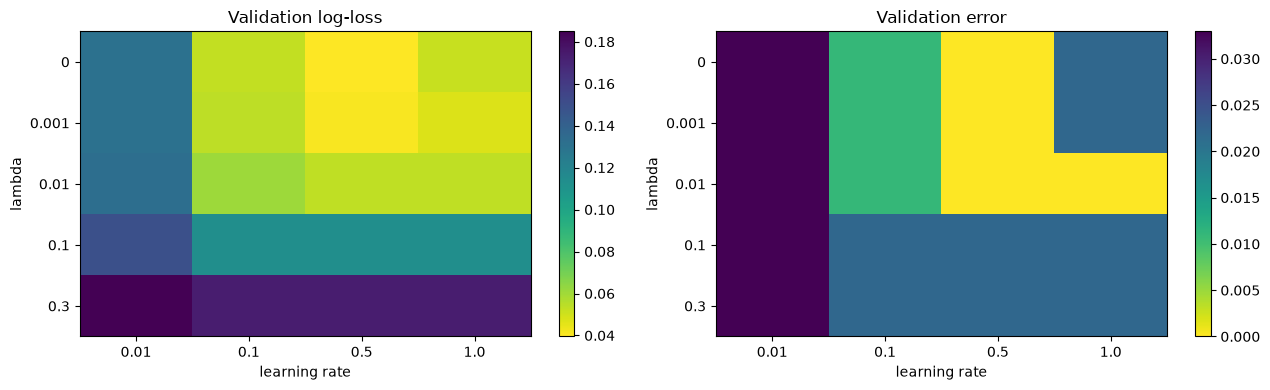

Best GD setting on validation data: lambda = 0, lr = 0.5


In [ ]:
lam_grid = [0, 1e-3, 1e-2, 1e-1, 0.3]
lr_grid  = [0.01, 0.1, 0.5, 1.0]

val_loss = pd.DataFrame(index=lam_grid, columns=lr_grid, dtype=float)
val_err  = pd.DataFrame(index=lam_grid, columns=lr_grid, dtype=float)

for lam, lr in itertools.product(lam_grid, lr_grid):
    w, _ = quiet(gradient_descent, x_fit, y_fit, lam, lr, np.zeros((d, 1)), max_epoch=300)
    val_loss.loc[lam, lr] = log_loss(w, x_val, y_val)
    val_err.loc[lam, lr]  = error_rate(w, x_val, y_val)

val_loss.index.name, val_loss.columns.name = 'lambda', 'lr'
val_err.index.name,  val_err.columns.name  = 'lambda', 'lr'
print('Validation log-loss (GD, 300 epochs)'); display(val_loss.round(4))
print('Validation error (GD, 300 epochs)');    display(val_err.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, table, title in zip(axes, [val_loss, val_err], ['Validation log-loss', 'Validation error']):
    im = ax.imshow(table.values.astype(float), cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(lr_grid)));  ax.set_xticklabels(lr_grid)
    ax.set_yticks(range(len(lam_grid))); ax.set_yticklabels(lam_grid)
    ax.set_xlabel('learning rate'); ax.set_ylabel('lambda'); ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# best cell = lowest validation log-loss 
best_lam, best_lr = np.unravel_index(np.argmin(val_loss.values.astype(float)), val_loss.shape)
best_lam, best_lr = lam_grid[best_lam], lr_grid[best_lr]
print(f'Best GD setting on validation data: lambda = {best_lam}, lr = {best_lr}')

### 3. Effect of lambda on the weights and accuracy


,train err,test err,||w||,#weights |w|>0.1
lambda,,,,
0.0000,0.0110,0.0351,4.1397,29
0.0001,0.0110,0.0351,4.0963,29
0.0010,0.0110,0.0351,3.7540,29
0.0100,0.0110,0.0351,2.3941,28
0.1000,0.0220,0.0439,1.1640,21
1.0000,0.0418,0.0526,0.4560,8


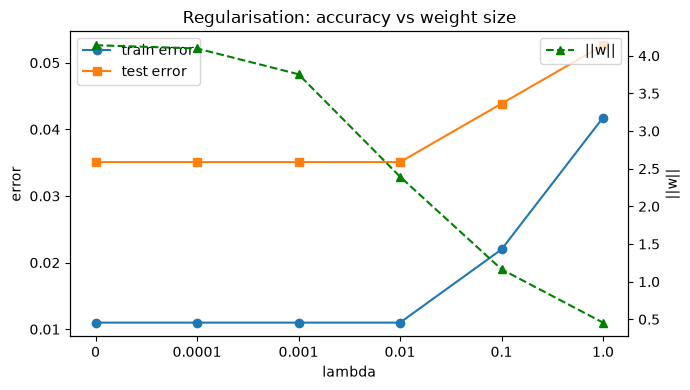

In [733]:
lams = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
rows = []
for lam in lams:
    w, _ = quiet(gradient_descent, x_train, y_train, lam, 0.5, np.zeros((d, 1)), max_epoch=500)
    rows.append({'lambda': lam,
                 'train err': error_rate(w, x_train, y_train),
                 'test err':  error_rate(w, x_test,  y_test),
                 '||w||':     np.linalg.norm(w),
                 '#weights |w|>0.1': int(np.sum(np.abs(w) > 0.1))})
lam_df = pd.DataFrame(rows).set_index('lambda')
display(lam_df.round(4))

fig, ax1 = plt.subplots(figsize=(7, 4))
xs = np.arange(len(lams))
ax1.plot(xs, lam_df['train err'], 'o-', label='train error')
ax1.plot(xs, lam_df['test err'],  's-', label='test error')
ax1.set_xticks(xs); ax1.set_xticklabels([str(l) for l in lams])
ax1.set_xlabel('lambda'); ax1.set_ylabel('error'); ax1.legend(loc='upper left')
ax2 = ax1.twinx(); ax2.plot(xs, lam_df['||w||'], 'g--^', label='||w||'); ax2.set_ylabel('||w||')
ax2.legend(loc='upper right'); plt.title('Regularisation: accuracy vs weight size'); plt.tight_layout(); plt.show()

### 4. Learning Rate sensitivity of GD, SGD and MBGD

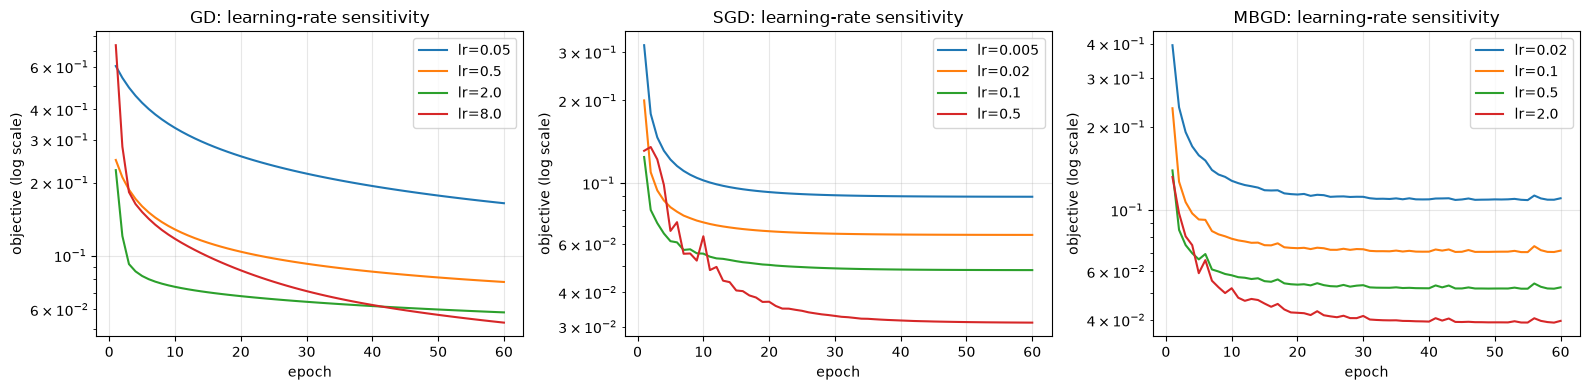

In [734]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lr_sets = {'GD': [0.05, 0.5, 2.0, 8.0], 'SGD': [0.005, 0.02, 0.1, 0.5], 'MBGD': [0.02, 0.1, 0.5, 2.0]}
for ax, (name, lrs) in zip(axes, lr_sets.items()):
    for lr in lrs:
        np.random.seed(0)
        if name == 'GD':
            _, ov = quiet(gradient_descent, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        elif name == 'SGD':
            _, ov = quiet(sgd, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        else:
            _, ov = quiet(mbgd, x_fit, y_fit, best_lam, lr, np.zeros((d, 1)), max_epoch=60)
        ax.plot(np.arange(1, 61), ov, label=f'lr={lr}')
    ax.set_yscale('log'); ax.set_title(f'{name}: learning-rate sensitivity')
    ax.set_xlabel('epoch'); ax.set_ylabel('objective (log scale)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5. Mini Batch Size per epoch Vs cost per second 

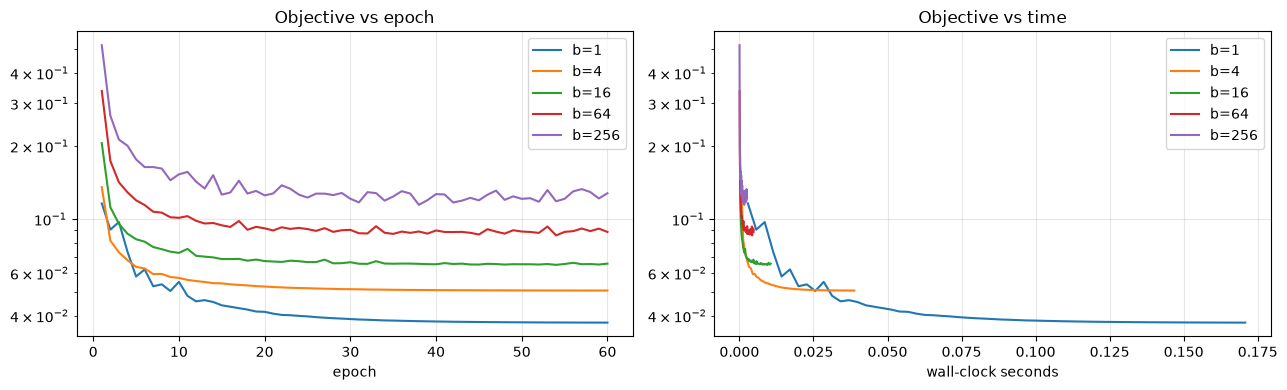

,updates/epoch,final objective,val err,seconds (60 ep)
batch size,,,,
1,364,0.0375,0.022,0.1708
4,91,0.0508,0.022,0.0388
16,23,0.0655,0.000,0.0105
64,6,0.0885,0.011,0.0048
256,2,0.1278,0.022,0.0025


In [735]:
sizes = [1, 4, 16, 64, 256]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for b in sizes:
    batch_size = b                      # mbgd reads this module-level setting
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(mbgd, x_fit, y_fit, best_lam, 0.3, np.zeros((d, 1)), max_epoch=60)
    secs = time.time() - t0
    axes[0].plot(np.arange(1, 61), ov, label=f'b={b}')
    axes[1].plot(np.cumsum(np.full(60, secs / 60)), ov, label=f'b={b}')
    rows.append({'batch size': b, 'updates/epoch': int(np.ceil(x_fit.shape[0] / b)),
                 'final objective': ov[-1], 'val err': error_rate(w, x_val, y_val),
                 'seconds (60 ep)': secs})
batch_size = 8                          # restore the default used in Section 3.3
axes[0].set_xlabel('epoch');        axes[0].set_title('Objective vs epoch')
axes[1].set_xlabel('wall-clock seconds'); axes[1].set_title('Objective vs time')
for ax in axes: ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index('batch size').round(4))

### 6. Final Comparison

In [736]:
final_cfg = {'GD':   dict(fn=gradient_descent, lr=best_lr, epochs=300),
             'SGD':  dict(fn=sgd,              lr=0.02,    epochs=60),
             'MBGD': dict(fn=mbgd,             lr=0.3,     epochs=100)}
rows = []
for name, cfg in final_cfg.items():
    np.random.seed(0)
    t0 = time.time()
    w, ov = quiet(cfg['fn'], x_train, y_train, best_lam, cfg['lr'], np.zeros((d, 1)), max_epoch=cfg['epochs'])
    rows.append({'method': name, 'lambda': best_lam, 'lr': cfg['lr'], 'epochs': cfg['epochs'],
                 'final objective': ov[-1],
                 'train err': error_rate(w, x_train, y_train),
                 'test err':  error_rate(w, x_test,  y_test),
                 'seconds': time.time() - t0})
display(pd.DataFrame(rows).set_index('method').round(4))

,lambda,lr,epochs,final objective,train err,test err,seconds
method,,,,,,,
GD,0,0.50,300,0.0528,0.0110,0.0351,0.0082
SGD,0,0.02,60,0.0576,0.0132,0.0351,0.1127
MBGD,0,0.30,100,0.0517,0.0110,0.0351,0.0422


### Conclusions from parameter tuning

**λ and learning rate (grid search, GD, validated on a held-out part of the training set)**
- The best setting was λ = 0 with lr = 0.5 (validation log-loss 0.040, validation error 0%).
- Validation loss gets worse as λ grows. At lr = 0.5 it goes from 0.040 (λ = 0) to 0.113 (λ = 0.1) and 0.173 (λ = 0.3).
- lr = 0.01 is too small to converge in 300 epochs. Its validation error stays at 3.3% for every λ.

**Regularization λ (GD, lr = 0.5, 500 epochs)**
- For λ ≤ 0.01, train error (1.10%) and test error (3.51%) stay the same, while ||w|| shrinks from 4.14 to 2.39.
- At λ = 0.1 and λ = 1, test error rises to 4.39% and 5.26%, and ||w|| falls to 1.16 and 0.46. The model underfits.
- With 455 samples and only 30 standardized features, the model doesn't overfit, so regularization doesn't help here. A very small λ (≤ 0.01) is fine.

**Learning rate (λ = 0, 60 epochs)**
- GD: lr = 0.05 is too slow (objective still 0.164 after 60 epochs). lr = 2.0 is fastest and best, with objective < 0.1 by epoch 3 and 0% validation error. lr = 8.0 overshoots (objective jumps to 0.74 in epoch 1) and ends with 3.3% validation error.
- SGD: lr = 0.02 is best (0% validation error). lr = 0.5 gets the lowest training objective but the worst validation error (4.4%) because single-sample steps are noisy.
- MBGD: lr = 0.1 is best (0% validation error). lr = 0.02 is too slow, and lr ≥ 0.5 converges quickly but with 2.2% validation error.
- A larger learning rate converges faster until it starts to overshoot or add noise. SGD and MBGD need much smaller rates than GD.

**Mini-batch size (MBGD, lr = 0.3, 60 epochs)**
- Smaller batches converge much further per epoch. The final objective is 0.038 for b = 1 and 0.128 for b = 256.
- They also cost more time: 0.74 s for b = 1 versus 0.008 s for b = 256.
- b = 16 is the best trade-off, with 0% validation error and a final objective of 0.066. It is about 15 times faster than b = 1.

**Final comparison (tuned settings, trained on the full training set, tested once)**
- GD, SGD and MBGD all reach a test error of 3.51% (96.49% accuracy).
- GD is cheapest per epoch (0.03 s), but SGD and MBGD need far fewer epochs to reach a low loss.

**Overall**
All three optimizers end at about 96.5% test accuracy. Tuning affects convergence speed and stability, not the final accuracy, and regularization isn't needed on this dataset.